In [13]:
import pandas as pd
from sklearn.cluster import KMeans
import seaborn as sns
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline

In [2]:
df = pd.read_csv('Mall_Customers.csv')
df.head(3)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6


In [3]:
df['Genre'] = df['Genre'].map({'Female' : 0, 'Male' : 1})

In [4]:
model = KMeans(n_clusters=3)

In [5]:
df['Result'] = model.fit_predict(df)

In [6]:
cluster_0 = df[df['Result'] == 0]
cluster_1 = df[df['Result'] == 1]
cluster_2 = df[df['Result'] == 2]

In [7]:
score = []
for i in range(2, 11):
    model = KMeans(n_clusters=i, random_state=42)
    model.fit(df)
    score.append(model.inertia_)
print(score)

[387110.15941594157, 271409.8927091963, 195421.08103854713, 157529.35724537587, 122767.94749596808, 113342.1221760689, 86221.60894838937, 82269.77503052501, 75299.0530560782]


In [8]:
pca_ = PCA(n_components=2, random_state=42)
updated_df =pca_.fit_transform(df)

In [9]:
updated_df[:,0]

array([-109.38757055, -108.20649296, -107.38013219, -106.0116116 ,
       -104.98428256, -103.77869047, -103.00065435, -101.43084855,
       -100.95654979,  -99.38482445,  -99.07513172,  -97.40848292,
        -96.78241233,  -95.25689838,  -94.84645306,  -93.40570091,
        -92.45480368,  -91.24690462,  -89.95228833,  -88.48025895,
        -87.57887528,  -86.35408717,  -85.61008428,  -84.15555155,
        -82.54721664,  -81.03403922,  -80.54876453,  -79.38351936,
        -78.29238552,  -76.90656219,  -76.35547935,  -74.75443166,
        -73.26463665,  -71.55994808,  -71.34928212,  -69.8256261 ,
        -69.05451108,  -67.69801008,  -65.90954087,  -64.57624243,
        -63.78589605,  -62.25221066,  -61.44536284,  -60.26662756,
        -59.6793146 ,  -58.37322524,  -57.27148071,  -56.27708016,
        -55.409294  ,  -54.50817896,  -52.81816869,  -51.75771799,
        -50.46555427,  -49.67647173,  -48.8112832 ,  -47.90705989,
        -46.55009636,  -45.76902688,  -43.76092642,  -43.03343

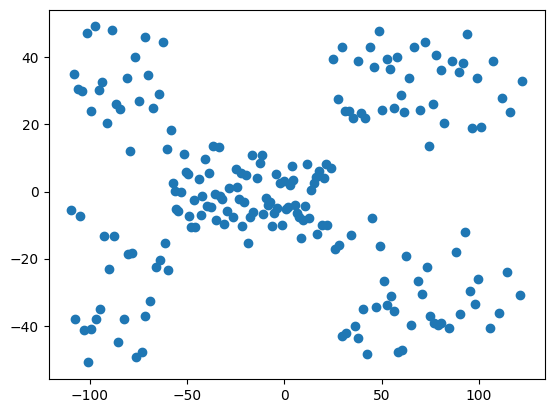

In [10]:
plt.scatter(updated_df[:, 0], updated_df[:, 1])

In [11]:
model = KMeans(n_clusters=4, random_state=42)
clusters = model.fit_predict(df)

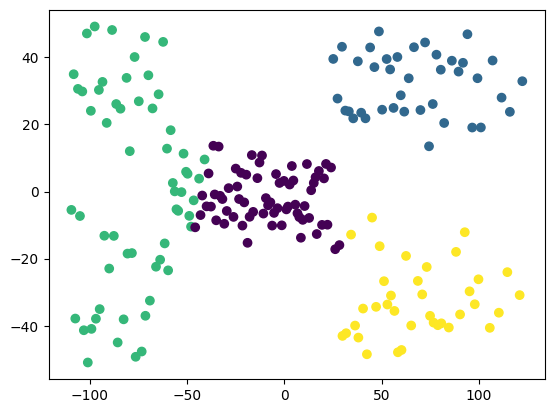

In [12]:
plt.scatter(updated_df[:, 0], updated_df[:, 1], c=clusters)

In [14]:
main_pipe = Pipeline(
    steps=[
        ('pca_', PCA(n_components=0.95)),
        ('model', KMeans(n_clusters=2, random_state=42))
    ]
)
main_pipe.fit_predict(df)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1])

In [15]:
main_pipe.fit_transform(df)

array([[ 55.42794568, 163.70690971],
       [ 64.32508392, 166.13553194],
       [ 65.21819983, 165.9887578 ],
       [ 60.1578936 , 163.11677079],
       [ 51.27284077, 159.37966958],
       [ 57.85021297, 160.78116062],
       [ 63.8929191 , 162.57903233],
       [ 66.69960582, 162.60382718],
       [ 69.07789813, 163.34004617],
       [ 51.18057683, 155.47190136],
       [ 60.67561081, 158.68088493],
       [ 65.46542501, 159.38632156],
       [ 56.94838127, 155.70259213],
       [ 51.00734102, 152.50305803],
       [ 53.60374281, 153.14385573],
       [ 51.03044295, 151.18704094],
       [ 40.41852476, 147.27571183],
       [ 42.31113182, 146.89410675],
       [ 42.43267806, 146.00065749],
       [ 59.09807681, 150.58056646],
       [ 35.85821175, 142.42433489],
       [ 41.39746563, 142.96497271],
       [ 54.78771016, 146.90128737],
       [ 38.81179475, 140.5524878 ],
       [ 47.40936164, 141.98659985],
       [ 43.21484312, 139.41747971],
       [ 32.14222181, 136.04490962],
 